# Anomaly detection for time series

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
from TSB_UAD.models.distance import Fourier
from TSB_UAD.models.feature import Window
from TSB_UAD.utils.slidingWindows import find_length,plotFig
from sklearn.preprocessing import MinMaxScaler

from TSB_UAD.models.norma import NORMA
from TSB_UAD.models.iforest import IForest
from TSB_UAD.models.lof import LOF
from TSB_UAD.models.matrix_profile import MatrixProfile
from TSB_UAD.models.pca import PCA
from TSB_UAD.models.poly import POLY
from TSB_UAD.models.ocsvm import OCSVM
from TSB_UAD.models.lstm import lstm
from TSB_UAD.models.AE_mlp2 import AE_MLP2
from TSB_UAD.models.cnn import cnn
from TSB_UAD.models.series2graph import Series2Graph

from TSB_UAD.models.damp import DAMP
from TSB_UAD.models.sand import SAND

2024-04-23 08:25:13.750714: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2024-04-23 08:25:13.750740: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


##  Data preprocessing

Here we load and prepare the time series (here, we load only a snippet of 10,000 points). We asutomatically estimate the subsequence length for the anomaly detection methods that require a subsequence length parameter.
In order to do this, we use auto-correlation

In [2]:
# Prepare data for unsupervised method

filepath = '../datasets/Dodgers/101-freeway-traffic.test.out'
columns = ['value', 'anomaly']
df = pd.read_csv(filepath, header=None, names=columns)
df = df[df['value'] >= 0].dropna().to_numpy()

name = filepath.split('/')[-1]

data = df[:,0].astype(float)
label = df[:,1].astype(int)
    
slidingWindow = find_length(data)
X_data = Window(window = slidingWindow).convert(data).to_numpy()


# Prepare data for semisupervised method. 
# Here, the training ratio = 0.1

data_train = data[:int(0.1*len(data))]
data_test = data

X_train = Window(window = slidingWindow).convert(data_train).to_numpy()
X_test = Window(window = slidingWindow).convert(data_test).to_numpy()

print("Estimated Subsequence length: ",slidingWindow)
print("Time series length: ",len(data))
print("Number of abnormal points: ",list(label).count(1))
print(df.shape)

Estimated Subsequence length:  288
Time series length:  47497
Number of abnormal points:  2709
(47497, 2)


## Display the results of 11 anomaly detectors

For each output figure, the left panel shows the real time series with outliers (red), anomaly score obtained by each anomaly detector, and the correpsonding TP/FP/TN/FN classification. 

The right panel shows the ROC curve. AUC represents the area under the ROC curve. Larger AUC indicates better performance.

(47210,)
(47497,)


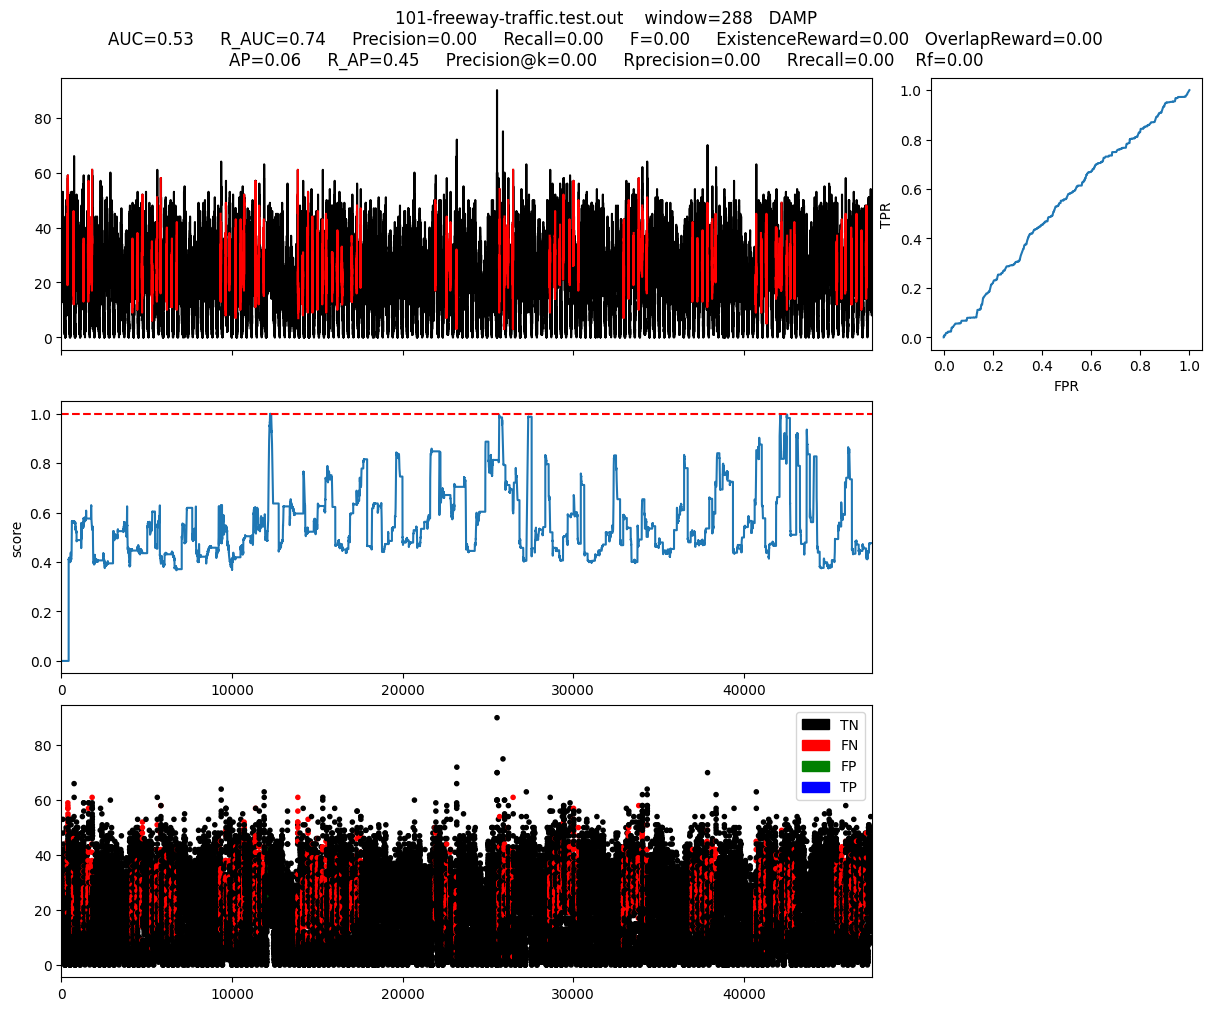

In [3]:
modelName='DAMP'
clf = DAMP(m = slidingWindow,sp_index=slidingWindow+1)
x = data
clf.fit(x)
score = clf.decision_scores_
print(score.shape)

score = MinMaxScaler(feature_range=(0,1)).fit_transform(score.reshape(-1,1)).ravel()
score = np.array([score[0]]*math.ceil((slidingWindow-1)/2) + list(score) + [score[-1]]*((slidingWindow-1)//2))
plotFig(data, label, score, slidingWindow, fileName=name, modelName=modelName) #, plotRange=[1775,2200]
print(score.shape)


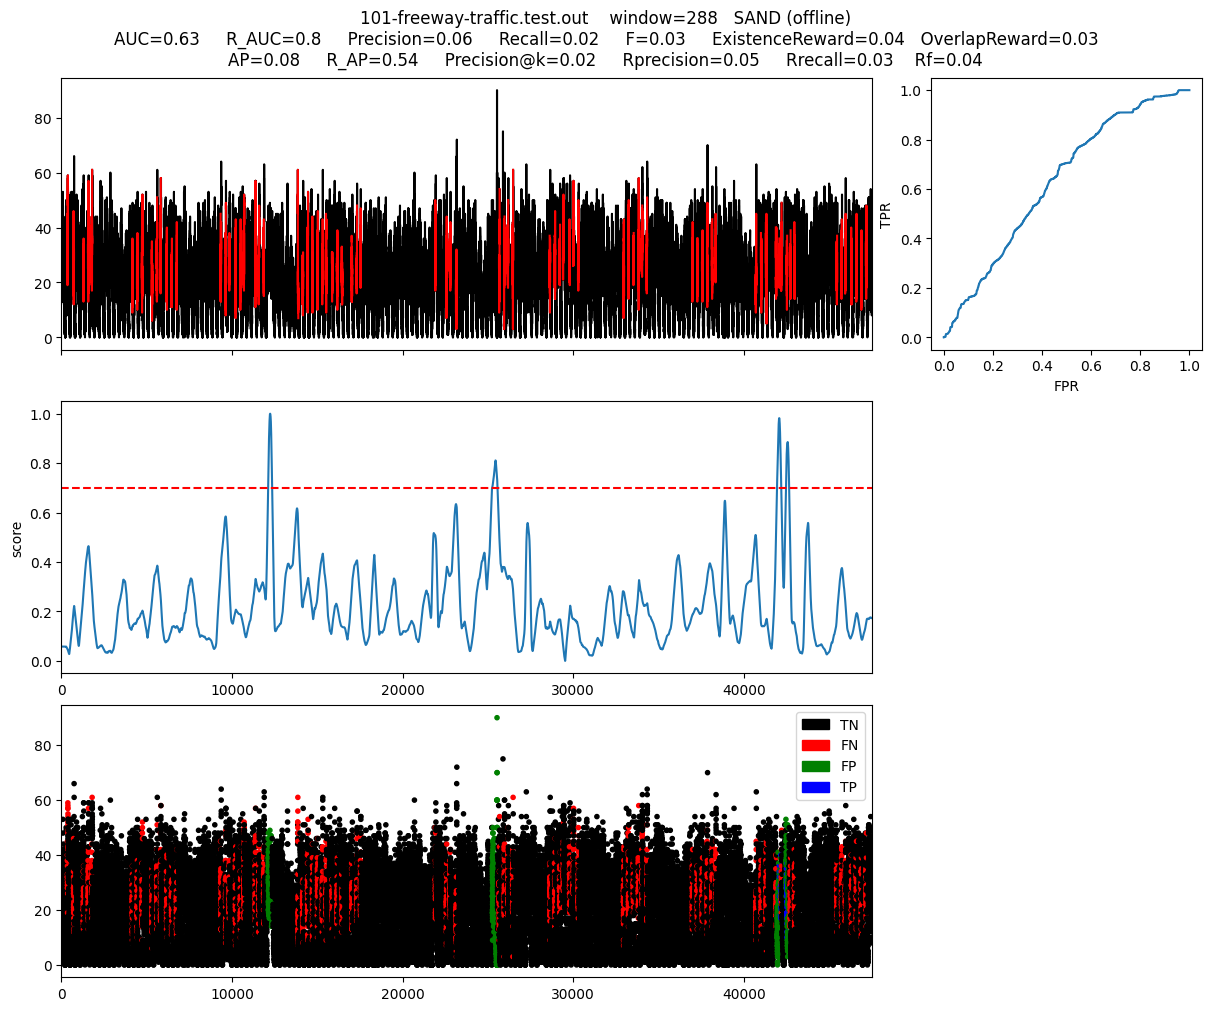

In [4]:
modelName='SAND (offline)'
clf = SAND(pattern_length=slidingWindow,subsequence_length=4*(slidingWindow))
x = data
clf.fit(x,overlaping_rate=int(1.5*slidingWindow))
score = clf.decision_scores_
score_sand_off = MinMaxScaler(feature_range=(0,1)).fit_transform(score.reshape(-1,1)).ravel()
plotFig(data, label, score_sand_off, slidingWindow, fileName=name, modelName=modelName) #, plotRange=[1775,2200]

0-->5000-->7000-->9000-->11000-->13000-->15000-->17000-->19000-->21000-->23000-->25000-->27000-->29000-->31000-->33000-->35000-->37000-->39000-->41000-->43000-->45000-->[STOP]: score length 47497


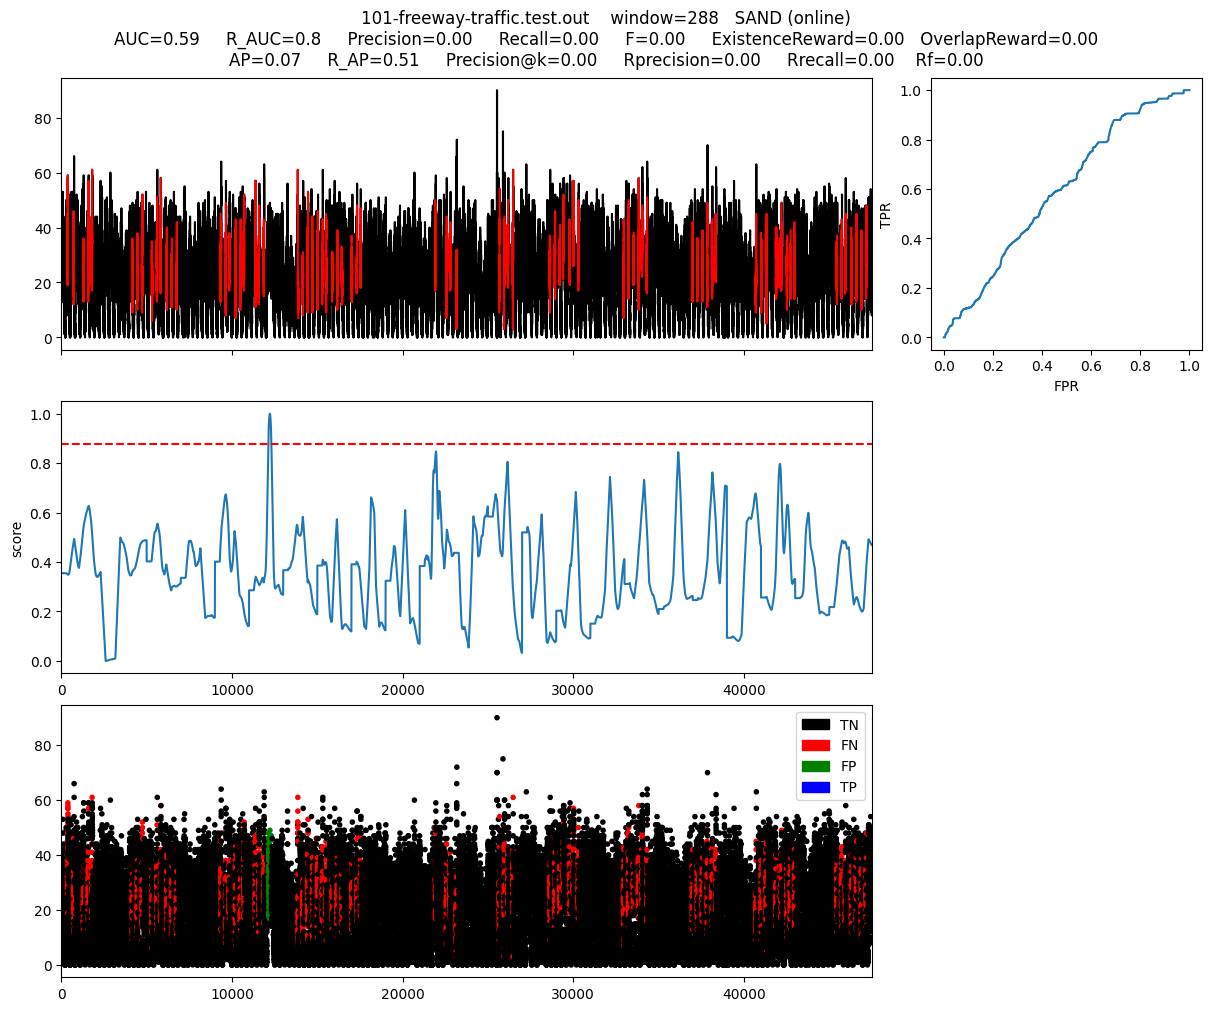

In [5]:
modelName='SAND (online)'
clf = SAND(pattern_length=slidingWindow,subsequence_length=4*(slidingWindow))
x = data
clf.fit(x,online=True,alpha=0.5,init_length=5000,batch_size=2000,verbose=True,overlaping_rate=int(4*slidingWindow))
score = clf.decision_scores_
score_sand_on = MinMaxScaler(feature_range=(0,1)).fit_transform(score.reshape(-1,1)).ravel()
plotFig(data, label, score_sand_on, slidingWindow, fileName=name, modelName=modelName) #, plotRange=[1775,2200]

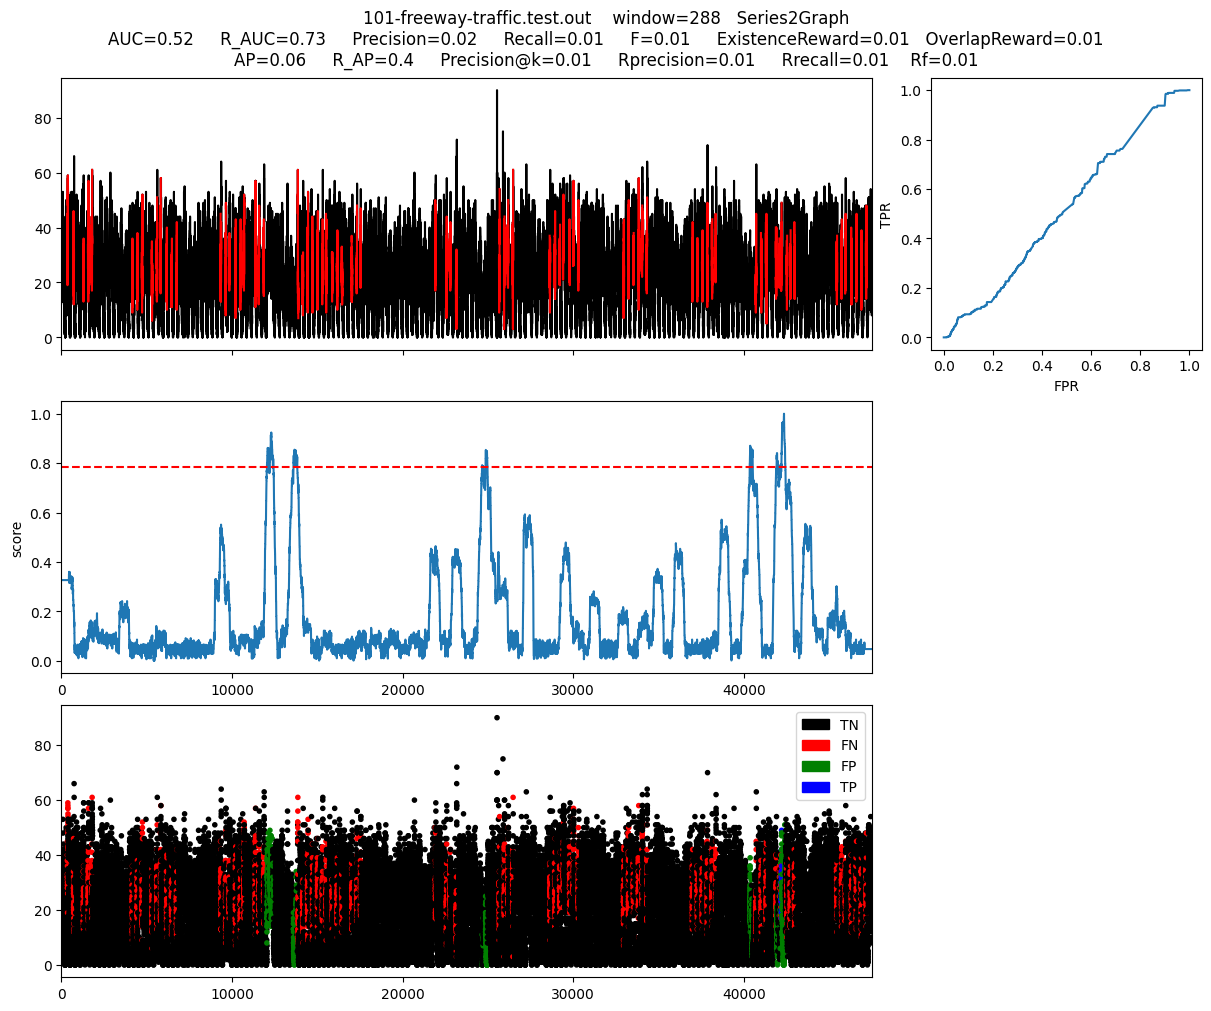

In [50]:
modelName='Series2Graph'
clf = Series2Graph(pattern_length=slidingWindow)
x = data
clf.fit(x)
query_length = slidingWindow*3
clf.score(query_length=query_length,dataset=data)
score = clf.decision_scores_
score = np.array([score[0]]*math.ceil(query_length//2) + list(score) + [score[-1]]*(query_length//2))
score_s2g = MinMaxScaler(feature_range=(0,1)).fit_transform(score.reshape(-1,1)).ravel()
plotFig(data, label, score_s2g, slidingWindow, fileName=name, modelName=modelName) #, plotRange=[1775,2200]

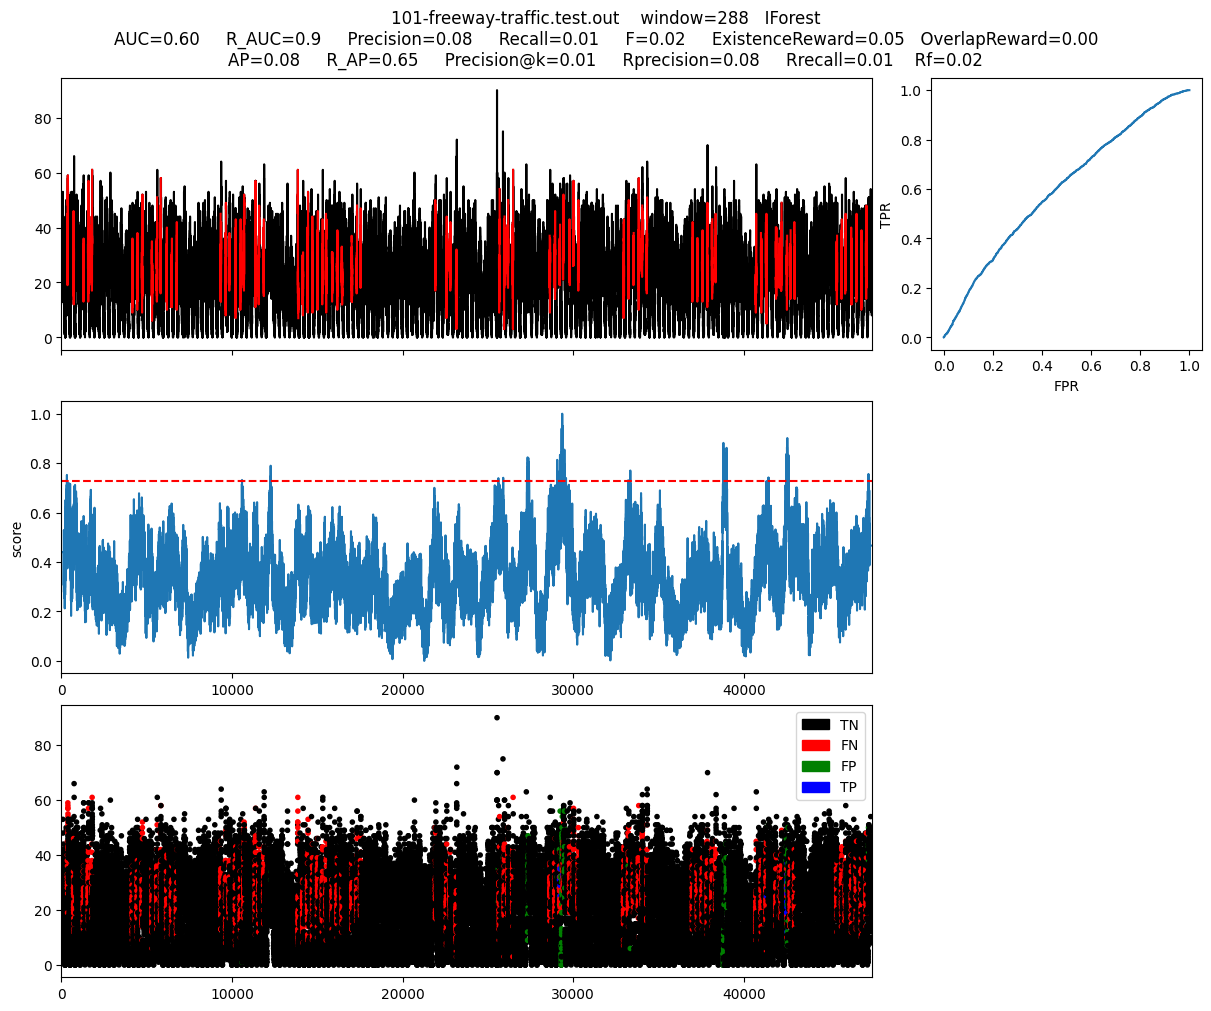

In [8]:
modelName='IForest'
clf = IForest(n_jobs=1, contamination=0.111)
x = X_data
clf.fit(x)
score = clf.decision_scores_
score = MinMaxScaler(feature_range=(0,1)).fit_transform(score.reshape(-1,1)).ravel()
score_if = np.array([score[0]]*math.ceil((slidingWindow-1)/2) + list(score) + [score[-1]]*((slidingWindow-1)//2))

plotFig(data, label, score_if, slidingWindow, fileName=name, modelName=modelName)

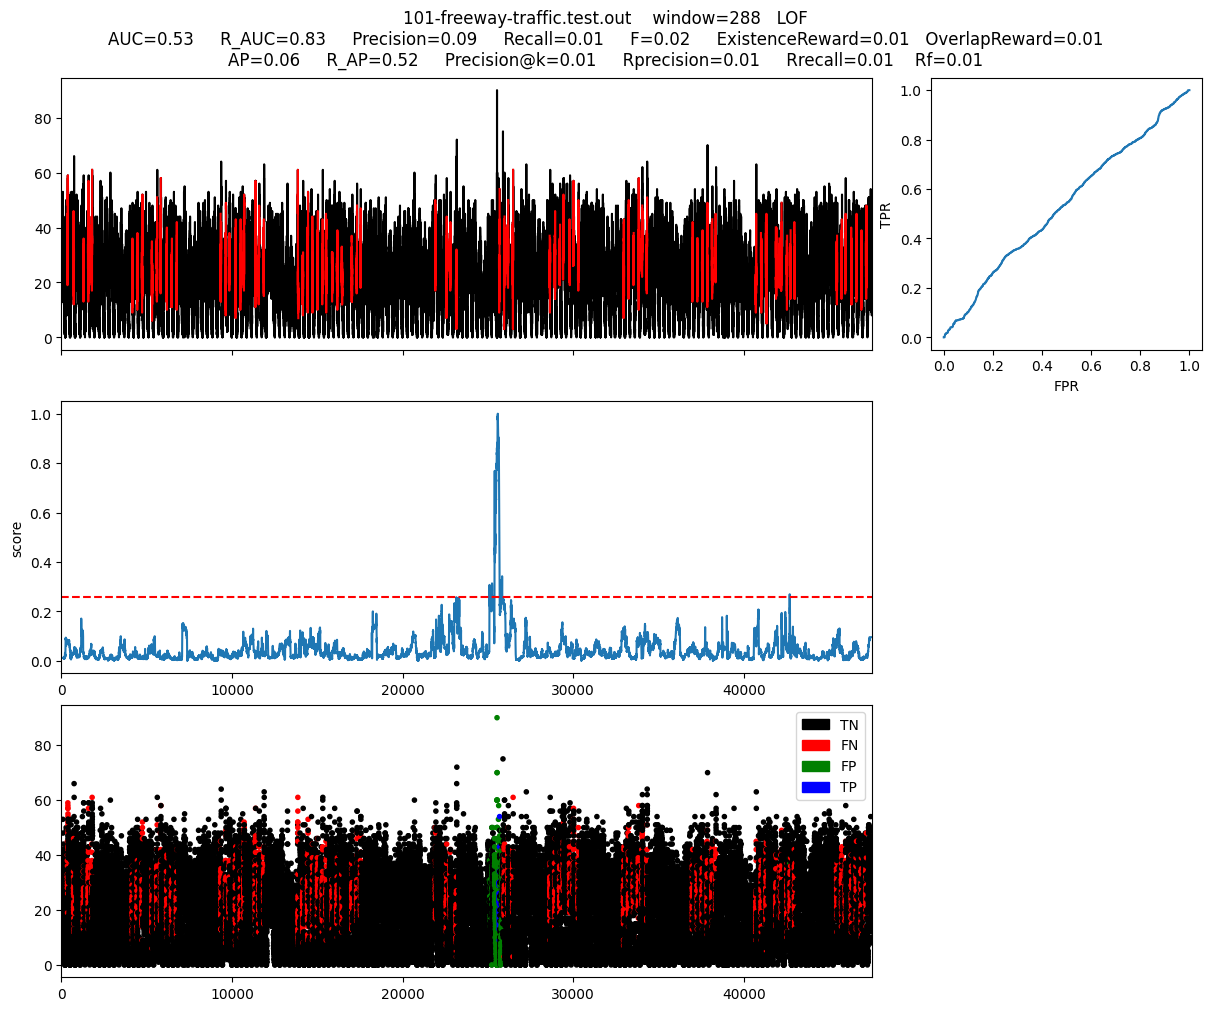

In [9]:
modelName='LOF'
clf = LOF(contamination=0.111, n_neighbors=20, n_jobs=-1)
x = X_data
clf.fit(x)
score = clf.decision_scores_
score = MinMaxScaler(feature_range=(0,1)).fit_transform(score.reshape(-1,1)).ravel()
score_lof = np.array([score[0]]*math.ceil((slidingWindow-1)/2) + list(score) + [score[-1]]*((slidingWindow-1)//2))

plotFig(data, label, score_lof, slidingWindow, fileName=name, modelName=modelName)

Normal Model Length/number of subsequences selected:  (864, 20)


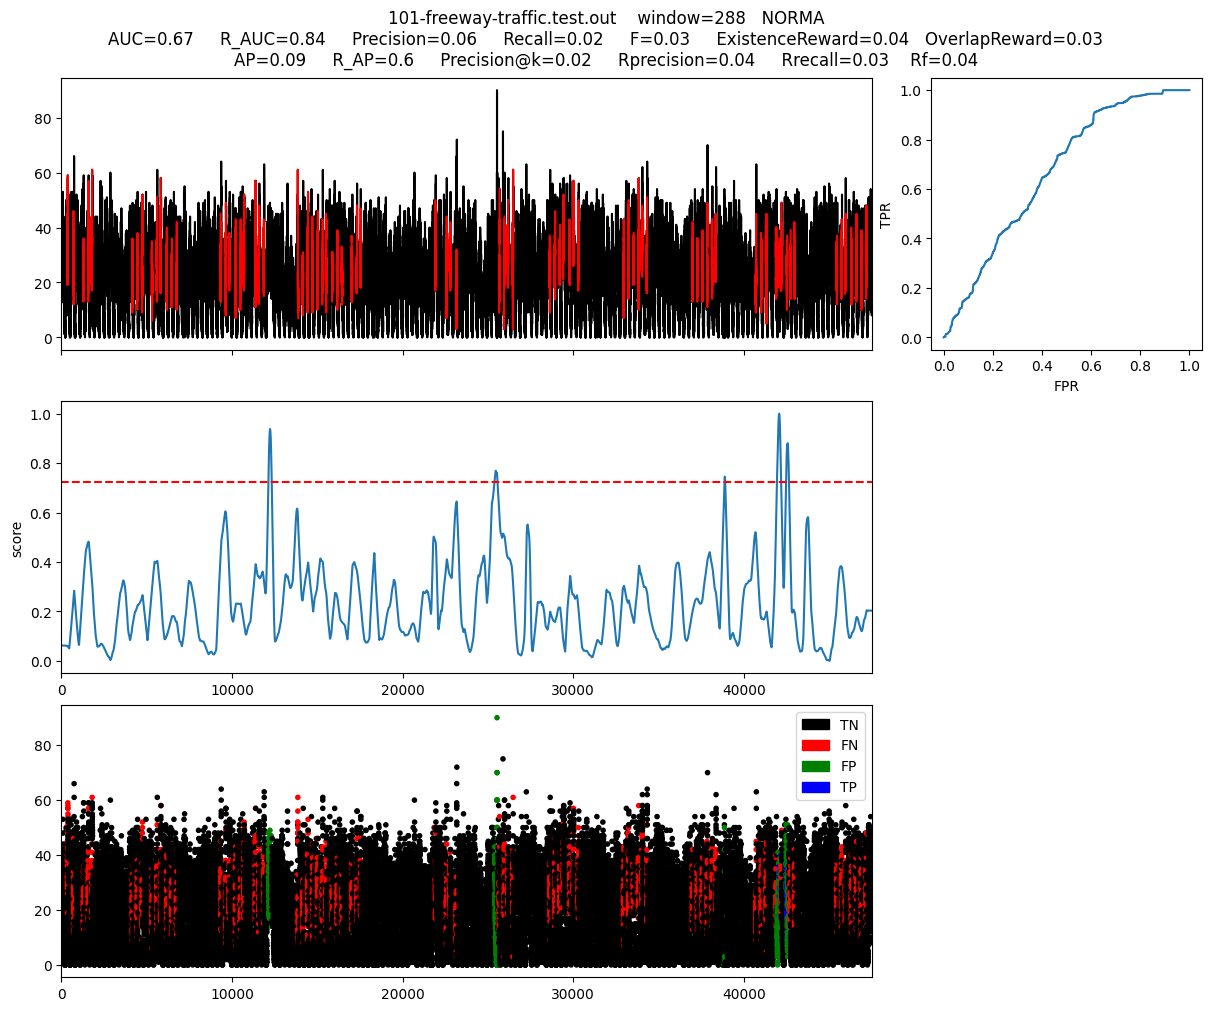

In [37]:
modelName='NORMA'
clf = NORMA(pattern_length = slidingWindow, nm_size=3*slidingWindow, number_of_cluster=30, percentage_sel=0.4, sampling_division=10, overlapping_factor=1)
x = data
clf.fit(x)
score = clf.decision_scores_
score = MinMaxScaler(feature_range=(0,1)).fit_transform(score.reshape(-1,1)).ravel()
score_norma = np.array([score[0]]*((slidingWindow-1)//2) + list(score) + [score[-1]]*((slidingWindow-1)//2))
plotFig(data, label, score_norma, slidingWindow, fileName=name, modelName=modelName)

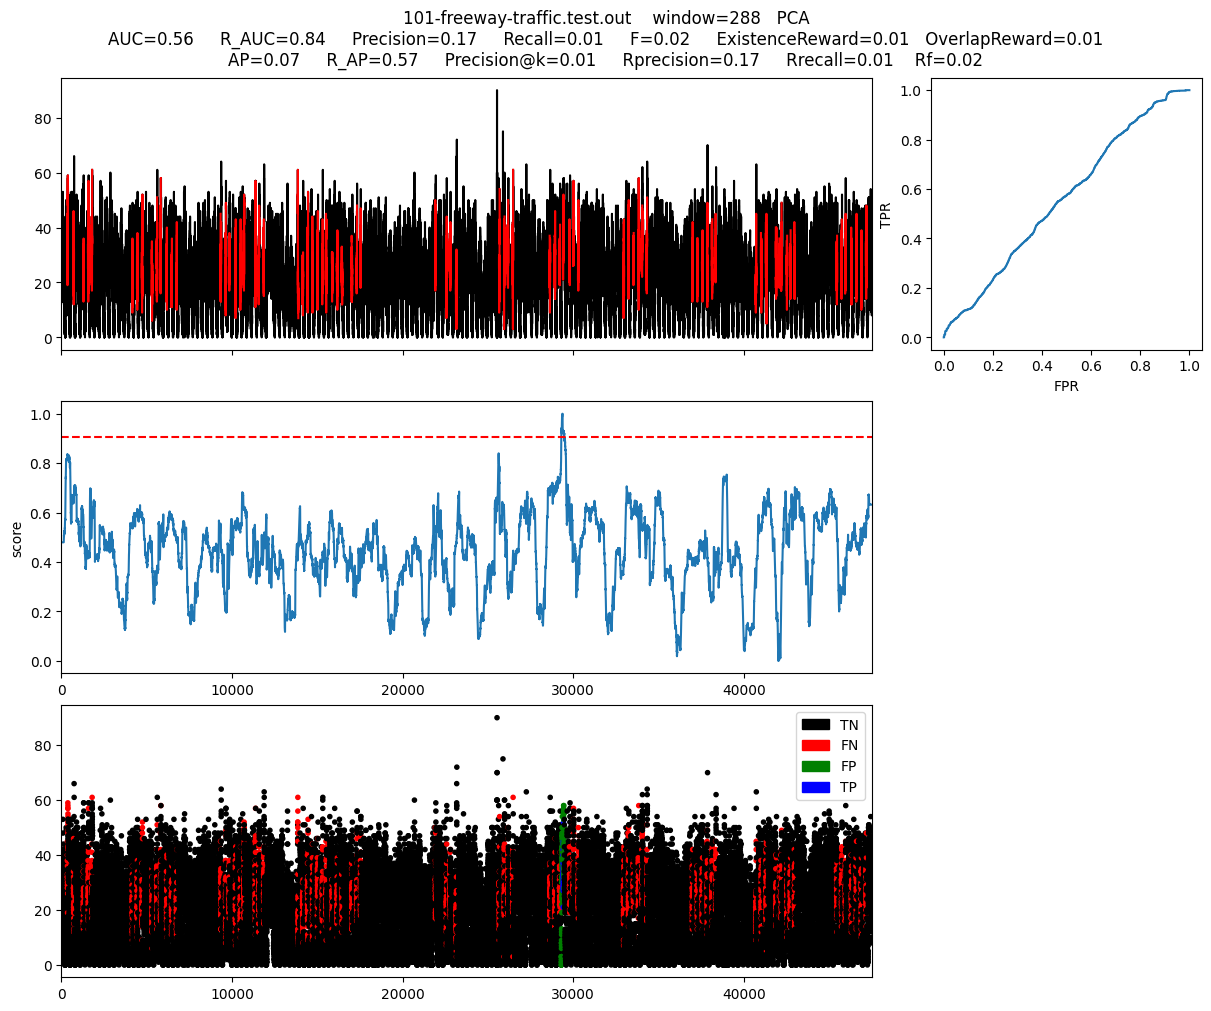

In [53]:
modelName='PCA'
clf = PCA(contamination=0.057, n_components=100, n_selected_components=75)
x = X_data
clf.fit(x)
score = clf.decision_scores_
score = MinMaxScaler(feature_range=(0,1)).fit_transform(score.reshape(-1,1)).ravel()
score_pca = np.array([score[0]]*math.ceil((slidingWindow-1)/2) + list(score) + [score[-1]]*((slidingWindow-1)//2))
plotFig(data, label, score_pca, slidingWindow, fileName=name, modelName=modelName)

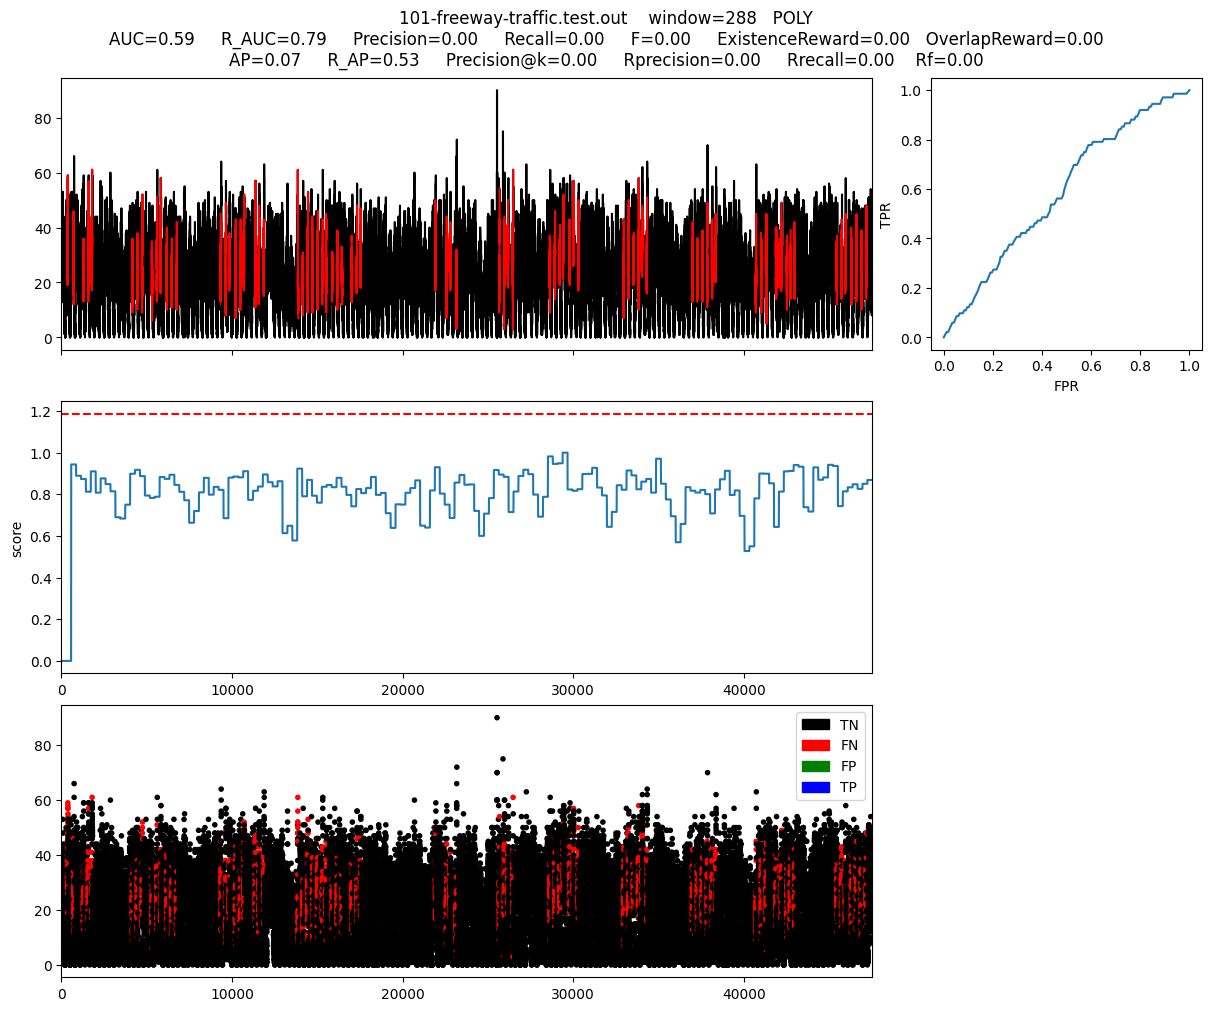

In [63]:
modelName='POLY'
clf = POLY(power=5, window = slidingWindow)
x = data
clf.fit(x)
measure = Fourier()
measure.detector = clf
measure.set_param()
clf.decision_function(measure=measure)
score = clf.decision_scores_
score_poly = MinMaxScaler(feature_range=(0,1)).fit_transform(score.reshape(-1,1)).ravel()
plotFig(data, label, score_poly, slidingWindow, fileName=name, modelName=modelName)

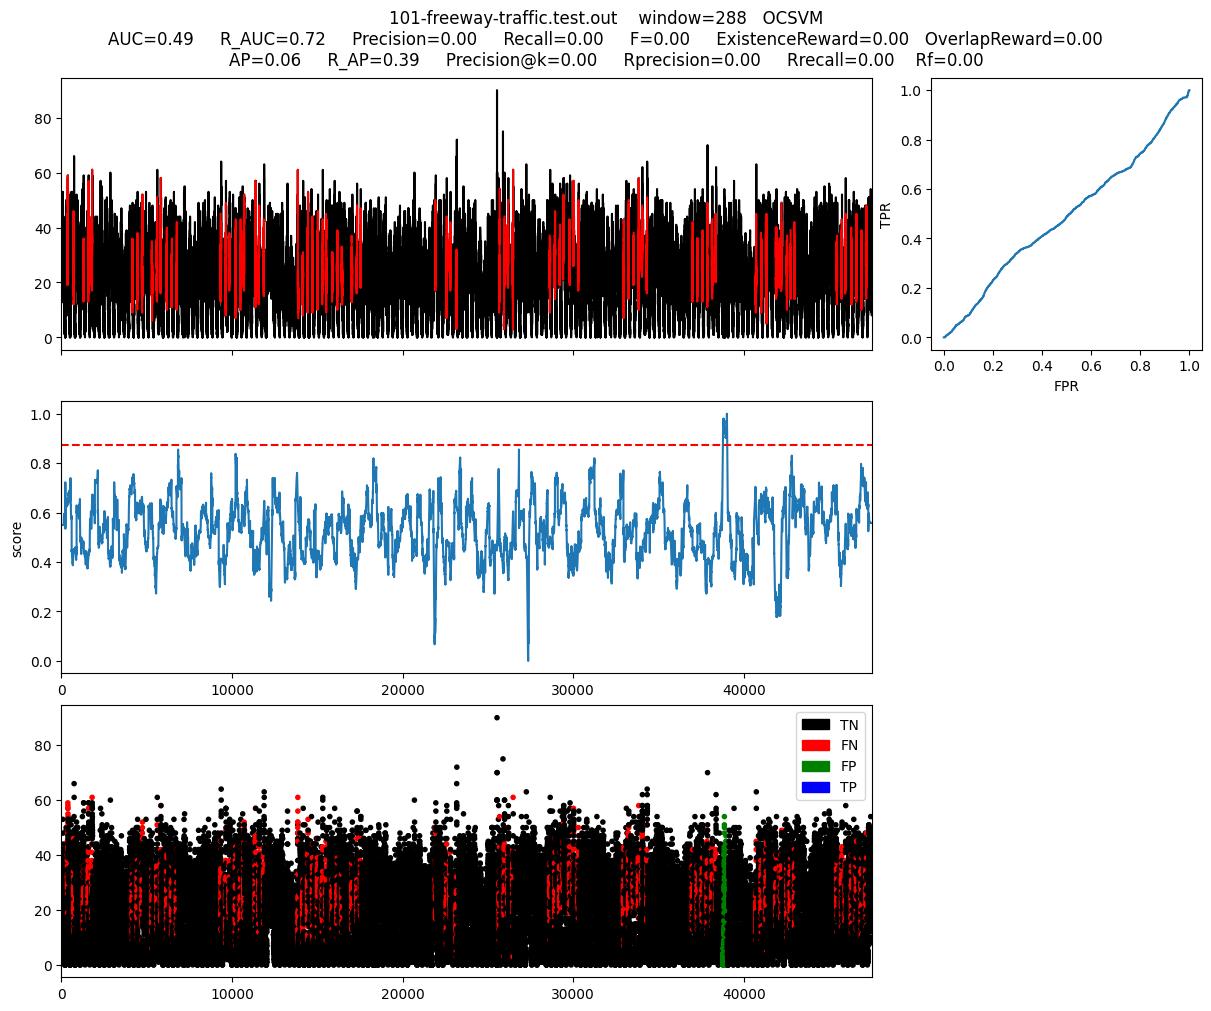

In [60]:
modelName='OCSVM'
X_train_ = MinMaxScaler(feature_range=(0,1)).fit_transform(X_train.T).T
X_test_ = MinMaxScaler(feature_range=(0,1)).fit_transform(X_test.T).T

clf = OCSVM(nu=0.05)
clf.fit(X_train_, X_test_)


score = clf.decision_scores_
score = np.array([score[0]]*math.ceil((slidingWindow-1)/2) + list(score) + [score[-1]]*((slidingWindow-1)//2))
score_ocsvm = MinMaxScaler(feature_range=(0,1)).fit_transform(score.reshape(-1,1)).ravel()

plotFig(data, label, score_ocsvm, slidingWindow, fileName=name, modelName=modelName)

2024-04-23 09:06:08.868652: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2024-04-23 09:06:08.868706: W tensorflow/stream_executor/cuda/cuda_driver.cc:269] failed call to cuInit: UNKNOWN ERROR (303)
2024-04-23 09:06:08.868738: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (rojan-Lenovo-ideapad-530S-14IKB): /proc/driver/nvidia/version does not exist
2024-04-23 09:06:08.869587: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


  40/1476 [..............................] - ETA: 1s  

2024-04-23 09:06:11.761826: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 54385920 exceeds 10% of free system memory.


1476/1476 [==============================] - 2s 1ms/step


2024-04-23 09:06:14.084060: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 54385920 exceeds 10% of free system memory.


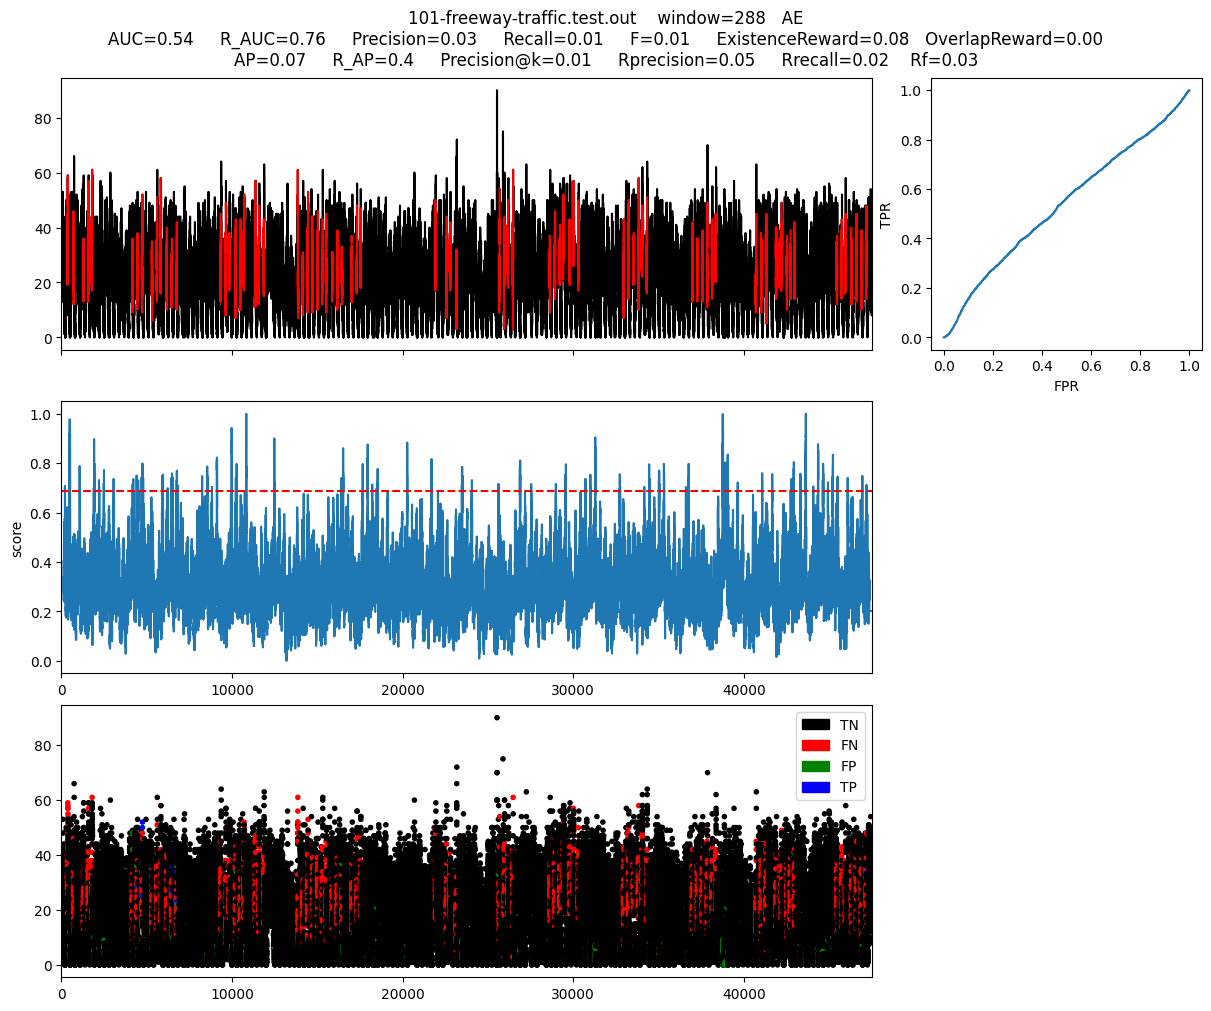

In [61]:
modelName='AE'
clf = AE_MLP2(slidingWindow = slidingWindow, epochs=100, verbose=0)

clf.fit(data_train, data_test)
        
score = clf.decision_scores_

score = MinMaxScaler(feature_range=(0,1)).fit_transform(score.reshape(-1,1)).ravel()

plotFig(data, label, score, slidingWindow, fileName=name, modelName=modelName)

In [62]:
score_list = [list(score_if), list(score_lof), list(score_s2g), list(score_norma), list(score_pca), list(score_ocsvm), list(score_sand_on), list(score_sand_off)]

In [46]:
import json

with open('scores.json', 'w') as file:
    json.dump(score_list, file)

In [4]:
import json

with open('scores.json', 'r') as file:
    loaded_score_list = json.load(file)

In [102]:
y_pred_if = [1 if scr > 0.8 else 0 for scr in score_if]
y_pred_lof = [1 if scr > 0.3 else 0 for scr in score_lof]
y_pred_s2g = [1 if scr > 0.5 else 0 for scr in score_s2g]
y_pred_norma = [1 if scr > 0.5 else 0 for scr in score_norma]
y_pred_pca = [1 if scr > 0.75 else 0 for scr in score_pca]
y_pred_sand_on = [1 if scr > 0.6 else 0 for scr in score_sand_on]
y_pred_sand_off = [1 if scr > 0.7 else 0 for scr in score_sand_off]

In [65]:
score_dict = {"IF": list(score_if), "LOF": list(score_lof), "S2G": list(score_s2g), "norma": list(score_norma), "PCA": list(score_pca), "SAND_ON": list(score_sand_on), "SAND_OFF": list(score_sand_off), "POLY": list(score_poly)}

In [71]:
import json

with open('../data/scores_dict_tsb_new.json', 'w') as file:
    json.dump(score_dict, file)

In [72]:
with open('../data/scores_dict_tsb_new.json', 'r') as file:
    tsb_score_list = json.load(file)

In [105]:
pred_list = [y_pred_if, y_pred_lof, y_pred_s2g, y_pred_norma, y_pred_pca, y_pred_sand_on, y_pred_sand_off]

In [106]:
label_dodgers = label

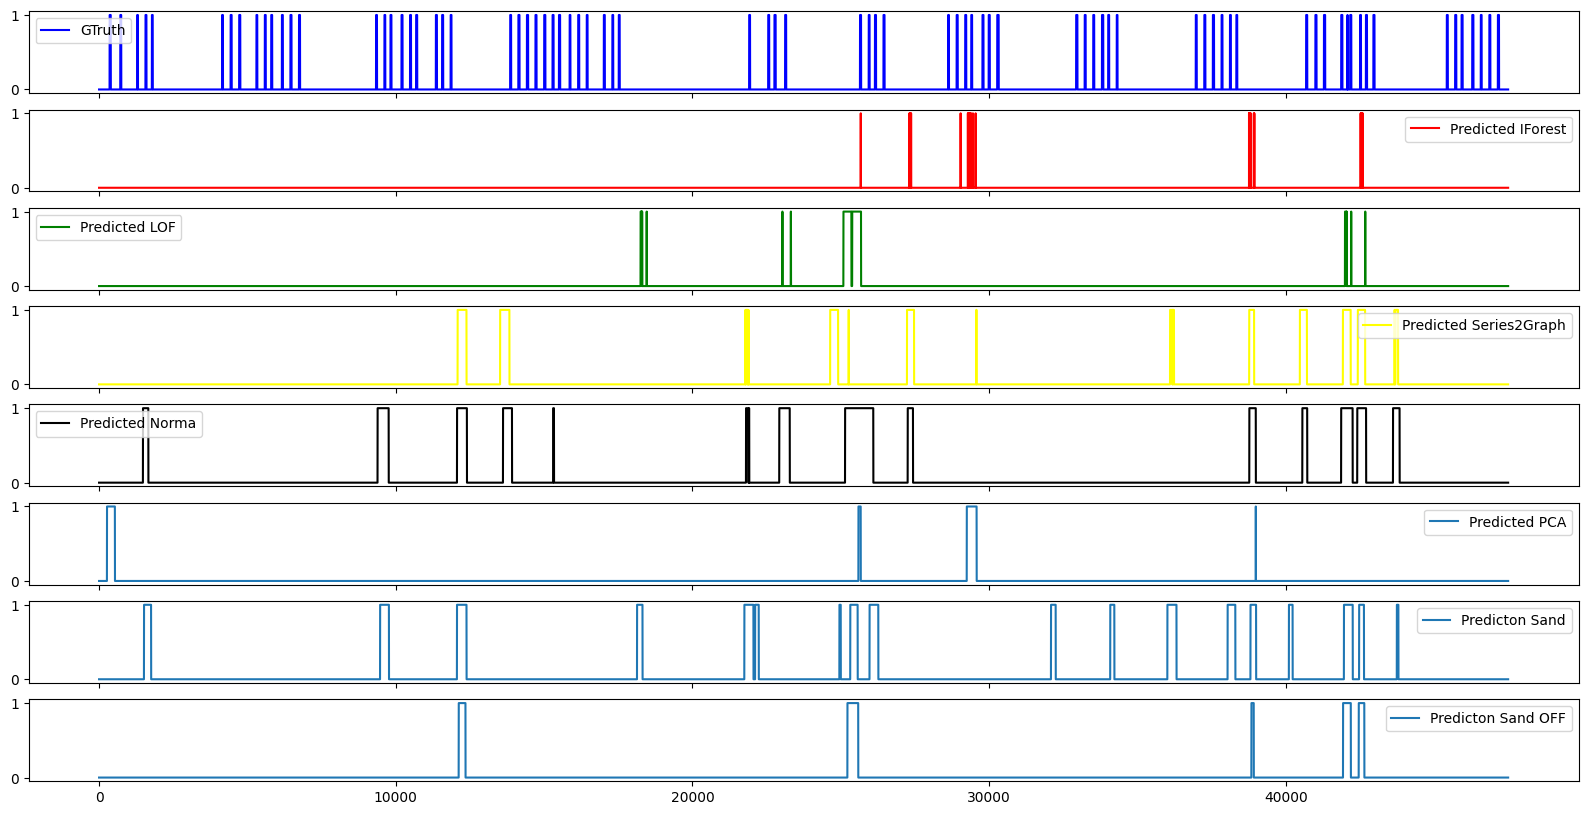

In [107]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(8, 1, sharex=True, figsize = (20, 10))
index = range(len(score_sand_on)) # 
index_df = range(len(label_dodgers))
index_sand = range(len(score_sand_on))

#gtruth.plot(ax=ax1, color='blue', label='GTruth')

axs[0].plot(index_df, label_dodgers, color='blue', label='GTruth')
axs[1].plot(index, y_pred_if, color='red', label='Predicted IForest')
axs[2].plot(index, y_pred_lof, color='green', label='Predicted LOF')
axs[3].plot(index, y_pred_s2g, color='yellow', label='Predicted Series2Graph')
axs[4].plot(index, y_pred_norma, color='black', label='Predicted Norma')
axs[5].plot(index, y_pred_pca, label='Predicted PCA')
axs[6].plot(index_sand, y_pred_sand_on, label='Predicton Sand')
axs[7].plot(index_sand, y_pred_sand_off, label='Predicton Sand OFF')

axs[0].legend(loc='upper left')
axs[1].legend(loc='upper right')
axs[2].legend(loc='upper left')
axs[3].legend(loc='upper right')
axs[4].legend(loc='upper left')
axs[5].legend(loc='upper right')
axs[6].legend()
axs[7].legend()

plt.show()

In [12]:
score_list = []
sample_gtruth = label_dodgers

for i, scr in enumerate(pred_list):

    sample_scr = scr
    score_list.append(sample_scr)

    prec1 = precision_score(sample_gtruth, sample_scr, pos_label=1)
    recall1 = recall_score(sample_gtruth, sample_scr, pos_label=1)
    f11 = f1_score(sample_gtruth, sample_scr, pos_label=1)
    rock = roc_auc_score(sample_gtruth, sample_scr, pos_label = 1)

    print(f'Model {i+1}: Precision Score: {prec1:.4f}  Recall: {recall1:.4f}  f1_score: {f11:.4f} roc_auc: {rock}')

NameError: name 'precision_score' is not defined

In [13]:
from TSB_UAD.utils.metrics import metricor

In [ ]:
grader = metricor()
label = label_dodgers
for i, scr in enumerate(pred_list):

    precision, recall, AP = grader.metric_PR(label, score)
    